# ============================================================
# 1. Построение дерева решений 
# ============================================================


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.path as mpath


class DecisionNode:
    # Узел решения (квадрат)
    def __init__(self, name, children=None):
        self.name = name
        self.children = children or {}  # {action_name: node}
        self.node_type = 'decision'

class ChanceNode:
    # Вероятностный узел (круг)
    def __init__(self, name, outcomes=None, probabilities=None):
        self.name = name
        self.outcomes = outcomes or {}  # {outcome_name: (probability, child_node)}
        self.node_type = 'chance'

class LeafNode:
    # Листовой узел (результат)
    def __init__(self, name, value):
        self.name = name
        self.value = value  # денежный выигрыш/убыток
        self.node_type = 'leaf'


# ============================================================
# 2. Построение дерева решений 
# ============================================================


In [9]:

# Быстрый релиз (Fast Release)
leaf_fast_success = LeafNode("Успех", 500000)           # успешный быстрый релиз
leaf_fast_partial = LeafNode("Частичный успех", 100000) # частичный успех
leaf_fast_failure = LeafNode("Провал", -300000)         # провал

# Тестирование (Testing)
leaf_test_success = LeafNode("Успех", 400000)
leaf_test_partial = LeafNode("Частичный успех", 150000)
leaf_test_failure = LeafNode("Провал", -150000)

# Отмена (Cancel)
leaf_cancel = LeafNode("Отмена релиза", -50000)

# ----- Вероятностные узлы (Уровень 2: Состояние среды) -----
# Для стратегии "Быстрый релиз"
fast_chance = ChanceNode("Состояние среды")
fast_chance.outcomes = {
    "Стабильная нагрузка": (0.5, leaf_fast_success),
    "Пиковая нагрузка": (0.3, leaf_fast_partial),
    "Сбой зависимости": (0.2, leaf_fast_failure)
}

# Для стратегии "Тестирование"
test_chance = ChanceNode("Состояние среды")
test_chance.outcomes = {
    "Стабильная нагрузка": (0.6, leaf_test_success),
    "Пиковая нагрузка": (0.3, leaf_test_partial),
    "Сбой зависимости": (0.1, leaf_test_failure)
}

# Для стратегии "Отмена" (нет неопределённости)
cancel_chance = ChanceNode("Состояние среды")
cancel_chance.outcomes = {
    "Отмена": (1.0, leaf_cancel)
}

# ----- Узлы решения (Уровень 1: Решение менеджера) -----
root = DecisionNode("Выбор стратегии выпуска")
root.children = {
    "Быстрый релиз": fast_chance,
    "Тестирование": test_chance,
    "Отмена": cancel_chance
}

# ============================================================
# 3. Функции для расчёта EMV и риска
# ============================================================



In [10]:
def calculate_emv_and_risk(node, path_prob=1.0):
    
    if node.node_type == 'leaf':
        return node.value, [(path_prob, node.value)]
    
    elif node.node_type == 'chance':
        total_emv = 0
        all_outcomes = []
        for outcome, (prob, child) in node.outcomes.items():
            child_emv, child_outcomes = calculate_emv_and_risk(child, path_prob * prob)
            total_emv += prob * child_emv
            all_outcomes.extend(child_outcomes)
        return total_emv, all_outcomes
    
    elif node.node_type == 'decision':
        # Для узла решения возвращаем лучший вариант
        best_emv = -np.inf
        best_outcomes = []
        best_action = None
        
        for action, child in node.children.items():
            action_emv, action_outcomes = calculate_emv_and_risk(child, path_prob)
            if action_emv > best_emv:
                best_emv = action_emv
                best_outcomes = action_outcomes
                best_action = action
        
        return best_emv, best_outcomes, best_action

def analyze_strategy(node, strategy_name, path_prob=1.0):
    if node.node_type == 'leaf':
        return node.value, [(path_prob, node.value)]
    
    elif node.node_type == 'chance':
        total_emv = 0
        all_outcomes = []
        for outcome, (prob, child) in node.outcomes.items():
            child_emv, child_outcomes = analyze_strategy(child, strategy_name, path_prob * prob)
            total_emv += prob * child_emv
            all_outcomes.extend(child_outcomes)
        return total_emv, all_outcomes
    
    elif node.node_type == 'decision':
        # Находим нужную стратегию
        if strategy_name in node.children:
            return analyze_strategy(node.children[strategy_name], strategy_name, path_prob)
        else:
            raise ValueError(f"Стратегия '{strategy_name}' не найдена")

def compute_stats(emv, outcomes):
    if len(outcomes) == 0:
        return emv, 0
    
    # outcomes: [(probability, value), ...]
    probs = [p for p, _ in outcomes]
    values = [v for _, v in outcomes]
    
    # Проверка: сумма вероятностей должна быть ~1
    # print(f"Сумма вероятностей: {sum(probs)}")
    
    # Дисперсия = E[X^2] - (E[X])^2
    e_x = emv
    e_x2 = sum(p * (v ** 2) for p, v in outcomes)
    variance = e_x2 - (e_x ** 2)
    risk = np.sqrt(max(0, variance))  # std
    
    return e_x, risk


# ============================================================
# 4. Расчёт для каждой стратегии
# ============================================================


In [11]:

strategies = ["Быстрый релиз", "Тестирование", "Отмена"]
results = {}

print("=" * 80)
print("Дерево решений: Выпуск нового функционала")
print("=" * 80)

for strategy in strategies:
    emv, outcomes = analyze_strategy(root, strategy)
    emv_final, risk = compute_stats(emv, outcomes)
    results[strategy] = {'EMV': emv_final, 'risk': risk, 'outcomes': outcomes}
    
    print(f"\n--- {strategy} ---")
    print(f"  Ожидаемая денежная стоимость (EMV): {emv_final:,.0f} руб.")
    print(f"  Риск (σ): {risk:,.0f} руб.")
    print(f"  Коэффициент вариации (σ/|EMV|): {risk/abs(emv_final):.3f}" if emv_final != 0 else "  Коэффициент вариации: N/A")
    print("  Распределение исходов:")
    for prob, value in outcomes:
        print(f"    {prob*100:.1f}% -> {value:+,.0f} руб.")

Дерево решений: Выпуск нового функционала

--- Быстрый релиз ---
  Ожидаемая денежная стоимость (EMV): 220,000 руб.
  Риск (σ): 312,410 руб.
  Коэффициент вариации (σ/|EMV|): 1.420
  Распределение исходов:
    50.0% -> +500,000 руб.
    30.0% -> +100,000 руб.
    20.0% -> -300,000 руб.

--- Тестирование ---
  Ожидаемая денежная стоимость (EMV): 270,000 руб.
  Риск (σ): 179,165 руб.
  Коэффициент вариации (σ/|EMV|): 0.664
  Распределение исходов:
    60.0% -> +400,000 руб.
    30.0% -> +150,000 руб.
    10.0% -> -150,000 руб.

--- Отмена ---
  Ожидаемая денежная стоимость (EMV): -50,000 руб.
  Риск (σ): 0 руб.
  Коэффициент вариации (σ/|EMV|): 0.000
  Распределение исходов:
    100.0% -> -50,000 руб.


# ============================================================
# 5. Выбор оптимальной стратегии на основе компромисса
# ============================================================


In [12]:
print("\n" + "=" * 80)
print("Выбор оптимальной стратегии")
print("=" * 80)

# Нормализация показателей для расчёта компромисса
emv_values = np.array([results[s]['EMV'] for s in strategies])
risk_values = np.array([results[s]['risk'] for s in strategies])

# Нормализация (min-max)
emv_norm = (emv_values - emv_values.min()) / (emv_values.max() - emv_values.min() + 1e-9)
risk_norm = 1 - (risk_values - risk_values.min()) / (risk_values.max() - risk_values.min() + 1e-9)
# risk_norm инвертирован: чем меньше риск, тем выше нормализованное значение

# Компромиссный критерий (с весами)
alpha = 0.6  # вес EMV (приоритет доходности)
beta = 0.4   # вес риска
score = alpha * emv_norm + beta * risk_norm

# Вывод в виде таблицы
print("\n{:<20} {:>15} {:>12} {:>15} {:>12} {:>15}".format(
    "Стратегия", "EMV (руб.)", "EMV норм.", "Риск (руб.)", "Риск норм.", "Итоговая оценка"
))
print("-" * 95)

for i, s in enumerate(strategies):
    print("{:<20} {:>15,.0f} {:>12.3f} {:>15,.0f} {:>12.3f} {:>15.3f}".format(
        s, results[s]['EMV'], emv_norm[i], results[s]['risk'], risk_norm[i], score[i]
    ))

print("-" * 95)

best_idx = np.argmax(score)
best_strategy = strategies[best_idx]

print(f"\n{'='*55}")
print(f"ОПТИМАЛЬНАЯ СТРАТЕГИЯ: {best_strategy}")
print(f"{'='*55}")
print(f"  EMV = {results[best_strategy]['EMV']:,.0f} руб.")
print(f"  Риск = {results[best_strategy]['risk']:,.0f} руб.")



Выбор оптимальной стратегии

Стратегия                 EMV (руб.)    EMV норм.     Риск (руб.)   Риск норм. Итоговая оценка
-----------------------------------------------------------------------------------------------
Быстрый релиз                220,000        0.844         312,410        0.000           0.506
Тестирование                 270,000        1.000         179,165        0.427           0.771
Отмена                       -50,000        0.000               0        1.000           0.400
-----------------------------------------------------------------------------------------------

ОПТИМАЛЬНАЯ СТРАТЕГИЯ: Тестирование
  EMV = 270,000 руб.
  Риск = 179,165 руб.


# ============================================================
# 6. Строим (садим) дерево решений
# ============================================================



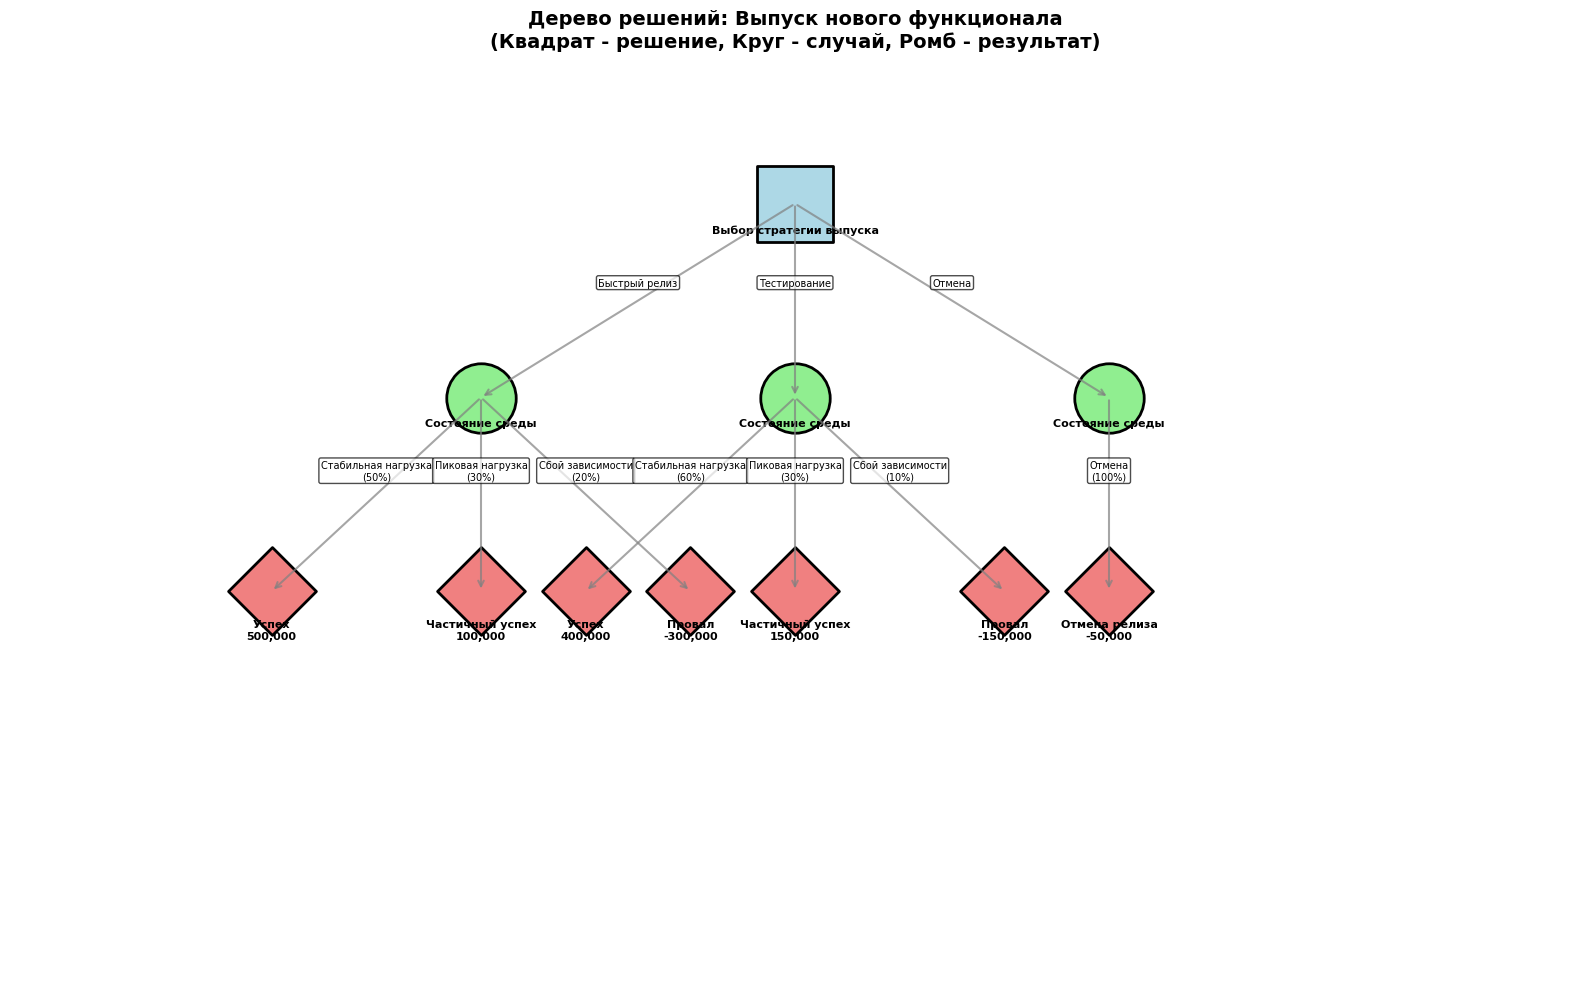

In [ ]:
def draw_tree(ax, node, x, y, level_width, vertical_spacing, level=0, max_level=3, parent_pos=None, edge_label=None):

    if node.node_type == 'decision':
        color = 'lightblue'
        shape = 's'  # квадрат
        node_size = 3000
    elif node.node_type == 'chance':
        color = 'lightgreen'
        shape = 'o'  # круг
        node_size = 2500
    else:  # leaf
        color = 'lightcoral'
        shape = 'd'  # ромб
        node_size = 2000
    
    if shape == 's':
        ax.scatter(x, y, s=node_size, c=color, marker='s', edgecolors='black', linewidth=2, zorder=3)
    elif shape == 'o':
        ax.scatter(x, y, s=node_size, c=color, marker='o', edgecolors='black', linewidth=2, zorder=3)
    else:
        ax.scatter(x, y, s=node_size, c=color, marker='D', edgecolors='black', linewidth=2, zorder=3)
    
    label = node.name
    if node.node_type == 'leaf':
        label += f"\n{node.value:,.0f}"
    ax.annotate(label, xy=(x, y), xytext=(0, -15 if node.node_type != 'leaf' else -20),
                textcoords='offset points', ha='center', va='top', fontsize=8, fontweight='bold')
    
    if parent_pos is not None and edge_label is not None:
        ax.annotate("", xy=(x, y), xytext=parent_pos,
                   arrowprops=dict(arrowstyle="->", color='gray', lw=1.5, alpha=0.7))
        # Подпись ребра
        mid_x = (parent_pos[0] + x) / 2
        mid_y = (parent_pos[1] + y) / 2 + 0.1
        ax.text(mid_x, mid_y, edge_label, fontsize=7, ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    if node.node_type == 'decision':
        n_children = len(node.children)
        for i, (action, child) in enumerate(node.children.items()):
            child_x = x + (i - (n_children-1)/2) * level_width
            child_y = y - vertical_spacing
            draw_tree(ax, child, child_x, child_y, level_width/1.5, vertical_spacing,
                     level+1, max_level, parent_pos=(x, y), edge_label=action)
    
    elif node.node_type == 'chance':
        n_outcomes = len(node.outcomes)
        for i, (outcome, (prob, child)) in enumerate(node.outcomes.items()):
            child_x = x + (i - (n_outcomes-1)/2) * level_width
            child_y = y - vertical_spacing
            edge_text = f"{outcome}\n({prob*100:.0f}%)"
            draw_tree(ax, child, child_x, child_y, level_width/1.5, vertical_spacing,
                     level+1, max_level, parent_pos=(x, y), edge_label=edge_text)


fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(-5, 5)
ax.set_ylim(-6, 1)
ax.axis('off')
ax.set_title("Дерево решений: Выпуск нового функционала\n(Квадрат - решение, Круг - случай, Ромб - результат)",
             fontsize=14, fontweight='bold', pad=20)

draw_tree(ax, root, x=0, y=0, level_width=2.0, vertical_spacing=1.5, max_level=3)

plt.tight_layout()
plt.show()